# Task 8: Background subtraction and alarm zone

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
video_path = 'images/samples_data_vtest.avi'
cap = cv2.VideoCapture(video_path)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames, w, h, fps

(795, 768, 576, 10.0)

In [3]:
zone = np.int32([[0, 380], [380, 380], [380, 576], [0, 576]])
warmup = 30
subtractor = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=50, detectShadows=True)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))


def process(frame, learning):
    mask = subtractor.apply(frame)
    mask = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY)[1]
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.dilate(mask, kernel, iterations=2)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    out = frame.copy()
    alarm = False
    for c in contours:
        if cv2.contourArea(c) < 800:
            continue
        x, y, bw, bh = cv2.boundingRect(c)
        feet = (x + bw // 2, y + bh)
        inside = cv2.pointPolygonTest(zone, feet, False) >= 0
        alarm = alarm or (inside and not learning)
        cv2.rectangle(out, (x, y), (x + bw, y + bh), (0, 0, 255) if inside else (0, 255, 0), 2)
    cv2.polylines(out, [zone], True, (0, 0, 255) if alarm else (255, 255, 0), 3)
    if alarm:
        cv2.putText(out, 'ALARM', (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4)
    return out, alarm

In [4]:

alarm_frames = []
samples = {}
i = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    out, alarm = process(frame, i < warmup)
    if alarm:
        alarm_frames.append(i)
    if i % 5 == 0:
        samples[i] = (out, alarm)
    i += 1
cap.release()

print('frames:', i, 'alarm frames:', len(alarm_frames))
print('first alarm at frame', alarm_frames[0] if alarm_frames else None)

frames: 795 alarm frames: 159
first alarm at frame 530


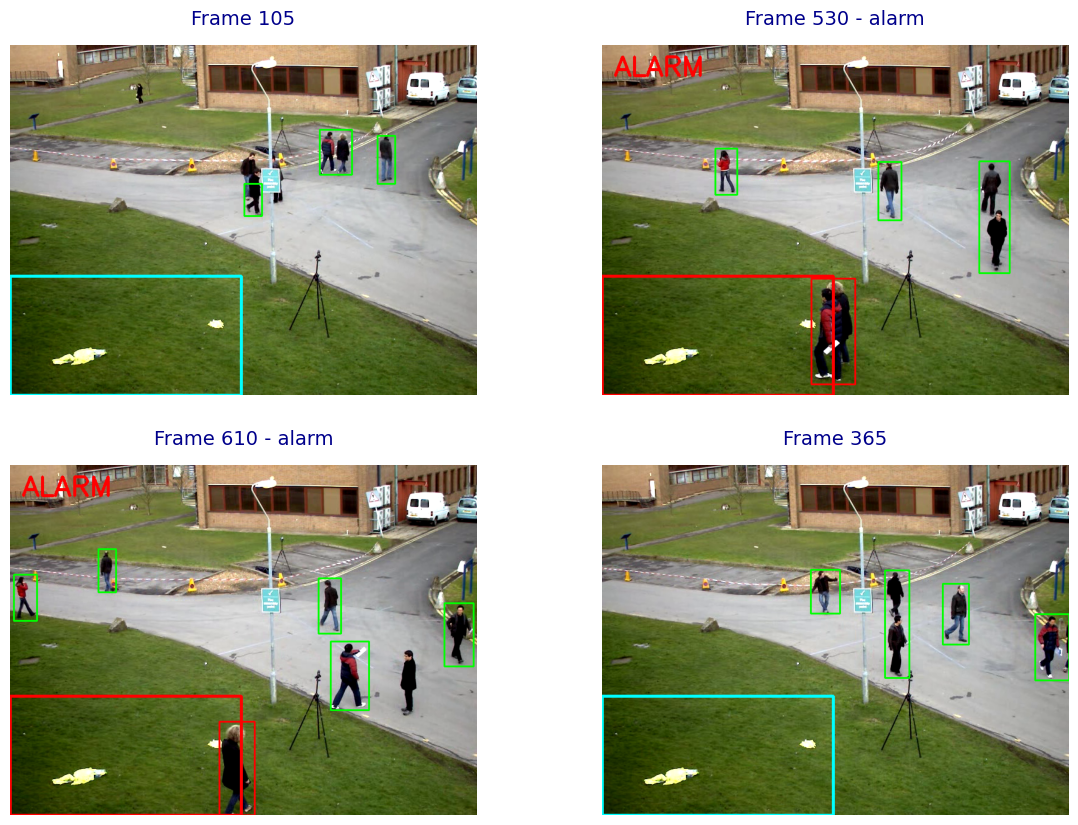

In [5]:
quiet = [k for k in samples if not samples[k][1] and k > 100]
loud = [k for k in samples if samples[k][1]]
pick = [quiet[0], loud[0], loud[len(loud) // 2], quiet[len(quiet) // 2]]
panels = [(f'Frame {k}' + (' - alarm' if samples[k][1] else ''), cv2.cvtColor(samples[k][0], cv2.COLOR_BGR2RGB)) for k in pick]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()